In [1]:
%matplotlib inline
import numpy as np
import os
import pandas as pd
import glob
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from scipy.cluster.hierarchy import linkage, dendrogram
import japanize_matplotlib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc


In [2]:
tasks = ["task1","task2"]
Days = [14, 17, 20, 24, 27, 31, 34, 38]
savefolder = "../data/220801results/"

def load_data(Day, task):
    if Day == 38:
        df_feature= pd.read_csv("../data/fftfeature/feature38.csv")
    elif Day == 34:
        df_feature= pd.read_csv("../data/fftfeature/feature34.csv")
    elif Day == 31:
        df_feature= pd.read_csv("../data/fftfeature/feature31.csv")
    elif Day == 27:
        df_feature= pd.read_csv("../data/fftfeature/feature27.csv")
    elif Day == 24:
        df_feature= pd.read_csv("../data/fftfeature/feature24.csv")
    elif Day == 20:
        df_feature= pd.read_csv("../data/fftfeature/feature20.csv")
    elif Day == 17:
        df_feature= pd.read_csv("../data/fftfeature/feature17.csv")
    elif Day == 14:
        df_feature= pd.read_csv("../data/fftfeature/feature14.csv")

    if task == "task20over":
        df_feature["FLAG"] = df_feature["score"] > 20
    elif task == "task10under":
        df_feature["FLAG"] = df_feature["score"] < 10
    elif task == "task15over":
        df_feature["FLAG"] = df_feature["score"] > 15
    return df_feature

def extractX(df):
    X = df.iloc[:,1:87].values
    return X

def X2df(X,df):
    _df = pd.DataFrame(X)
    _df["batchno"]=df["batchno"].values
    _df["day"]=df["day"].values
    _df["score"]=df["score"].values
    _df["FLAG"]=df["FLAG"].values
    return _df

def idx_of_the_nearest(data, value):
    idx = np.argmin(np.abs(np.array(data) - value))
    return idx

In [14]:
df_feature = load_data(38,"task20over")
X = extractX(df_feature)
y = df_feature["FLAG"].values
dish = df_feature["dish"].values
#unique_publisher = np.unique(dish)
dish_flag = df_feature[["dish","FLAG"]].drop_duplicates()
unique_publisher = dish_flag["dish"].values
flag_publisher = dish_flag["FLAG"].values

kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=100)
for fold, (tr_group_idx, va_group_idx) in enumerate(kf.split(unique_publisher, flag_publisher)):
    tr_groups, va_groups = unique_publisher[tr_group_idx], unique_publisher[va_group_idx]
    print("train:", tr_groups)
    print("test:", va_groups)

train: ['/Day38/#8/#8_0.5A' '/Day38/#8/#8_1A' '/Day38/#8/#8_2A'
 '/Day38/#8/#8_0.5B' '/Day38/#8/#8_2B' '/Day38/#9/#9_1A' '/Day38/#9/#9_1B'
 '/Day38/#10/#10_0.5A' '/Day38/#10/#10_1A' '/Day38/#10/#10_1B'
 '/Day38/#10/#10_2B' '/Day38/#11/#11_1A' '/Day38/#11/#11_0.5B'
 '/Day38/#11/#11_1B' '/Day38/#11/#11_2B' '/Day38/#12/#12_0.5A'
 '/Day38/#12/#12_1A' '/Day38/#12/#12_2A' '/Day38/#12/#12_0.5B'
 '/Day38/#12/#12_1B' '/Day38/#13/#13_0.3-0.5' '/Day38/#13/#13_0.3-1'
 '/Day38/#13/#13_0.3-2' '/Day38/#13/#13_0.5-0.5' '/Day38/#13/#13_0.5-2']
test: ['/Day38/#8/#8_1B' '/Day38/#9/#9_2A' '/Day38/#9/#9_2B' '/Day38/#10/#10_2A'
 '/Day38/#10/#10_0.5B' '/Day38/#11/#11_0.5A' '/Day38/#11/#11_2A'
 '/Day38/#12/#12_2B' '/Day38/#13/#13_0.5-1']
train: ['/Day38/#8/#8_1A' '/Day38/#8/#8_2A' '/Day38/#8/#8_1B' '/Day38/#8/#8_2B'
 '/Day38/#9/#9_1A' '/Day38/#9/#9_2A' '/Day38/#9/#9_1B' '/Day38/#9/#9_2B'
 '/Day38/#10/#10_2A' '/Day38/#10/#10_0.5B' '/Day38/#10/#10_1B'
 '/Day38/#10/#10_2B' '/Day38/#11/#11_0.5A' '/Day38/#11/#11_1

In [6]:
def do_cv(df_feature, FOLD, seed, textlog, logging):
    X = extractX(df_feature)
    y = df_feature["FLAG"].values
    dish = df_feature["dish"].values
    #unique_publisher = np.unique(dish)
    dish_flag = df_feature[["dish","FLAG"]].drop_duplicates()
    unique_publisher = dish_flag["dish"].values
    flag_publisher = dish_flag["FLAG"].values

    acc_scores = []
    pre_scores = []
    rec_scores = []
    f1_scores = []
    auc_scores = []
    
    y_vaild_list = []
    y_valid_pred_list = []

    kf = StratifiedKFold(n_splits=FOLD, shuffle=True, random_state=seed)
    if logging:
        textlog.write("seed:"+str(seed)+"\n")
    
    
    for fold, (tr_group_idx, va_group_idx) in enumerate(kf.split(unique_publisher, flag_publisher)):

        #データを分割
        tr_groups, va_groups = unique_publisher[tr_group_idx], unique_publisher[va_group_idx]
        if logging:
            textlog.write("KFOLD:CV="+str(fold)+"\n")
            textlog.write("train:\n")
            textlog.write(str(tr_groups)+"\n")
            textlog.write("valid:\n")
            textlog.write(str(va_groups)+"\n")
        
        
        is_tr = np.isin(dish, tr_groups)
        is_va = np.isin(dish, va_groups)

        X_train, X_valid = X[is_tr], X[is_va]
        y_train, y_valid = y[is_tr], y[is_va]

        # Train
        #教師データをPCA
        pca = PCA()
        X_pca_train = pca.fit_transform(X_train)
        #教師データをPLS
        pls = PLSRegression(n_components=2)
        X_pls_train = pls.fit_transform(X_pca_train, y_train)
        X_dat_train = np.hstack((X_pls_train[0],X_pca_train[:,:10]))

        # Train model
        model = RandomForestClassifier()
        #model = XGBClassifier()
        model.fit(X_dat_train, y_train)

        # Validation
        # 各画像から特徴量抽出(pca+pls)
        X_pca_valid = pca.transform(X_valid)
        X_pls_valid = pls.transform(X_pca_valid)
        X_dat_valid = np.hstack((X_pls_valid,X_pca_valid[:,:10]))


        y_valid_pred = model.predict(X_dat_valid)
        y_proba = model.predict_proba(X_dat_valid)
        fpr, tpr, thresholds = roc_curve(y_true=y_valid, y_score=y_proba[:,1])
        acc_scores.append(accuracy_score(y_true=y_valid, y_pred=y_valid_pred))
        pre_scores.append(precision_score(y_true=y_valid, y_pred=y_valid_pred))
        rec_scores.append(recall_score(y_true=y_valid, y_pred=y_valid_pred))
        f1_scores.append(f1_score(y_true=y_valid, y_pred=y_valid_pred))
        auc_scores.append(auc(fpr, tpr))
    if logging:
        textlog.write("\n")

    return [seed, np.mean(acc_scores), np.mean(pre_scores), np.mean(rec_scores), np.mean(f1_scores), np.mean(auc_scores)]

def do_experiments(task, Days, n_exp, FOLD=4,savefolder = savefolder):
    results = []
    textlog = open(savefolder+task+"/FOLD_"+str(FOLD)+"_n="+str(n_exp)+'_logfile.txt', 'w', encoding='UTF-8')
    for i in range(n_exp):
        for Day in Days:
            df_feature = load_data(Day,task)
            if Day == 38:
                log = True
            else:
                log = False
            _results = do_cv(df_feature, FOLD=FOLD, seed=i+100, textlog=textlog, logging = log)
            _results.append(Day)
            results.extend(_results)
    textlog.close()
    results = np.array(results).reshape(n_exp*len(Days),7)
    results = pd.DataFrame(results, columns=["seed","accuracy", "precision", "recall", "f1", "AUC","Day"])
    results.to_csv(savefolder+task+"/FOLD_"+str(FOLD)+"_n="+str(n_exp)+"_result_bugfixed"+".csv")
    return results

## Do experiment

In [16]:
results20 = do_experiments("task20over", Days, 100)
results10 = do_experiments("task10under", Days, 100)
#results15 = do_experiments("task15over", Days, 50)

/Users/taku/opt/anaconda3/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/taku/opt/anaconda3/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Generate violinplot

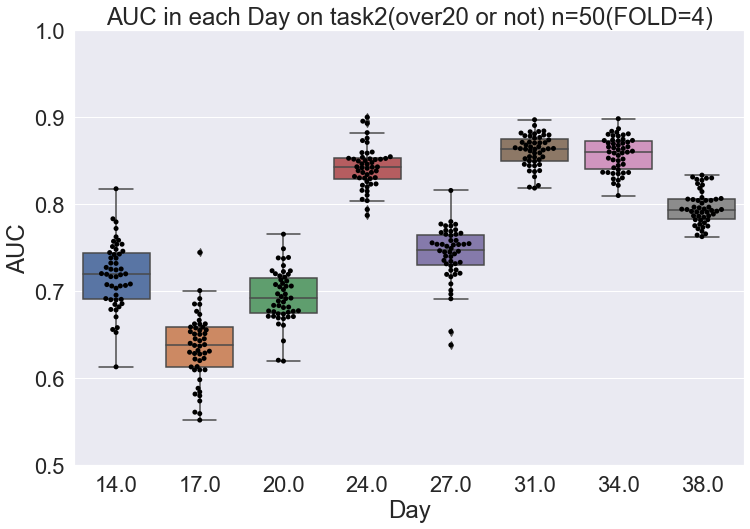

In [10]:
results20 = pd.read_csv(savefolder+"/task20over"+"/Task2FOLD_4_n=50_result_bugfixed.csv")

plt.figure(figsize=(12,8))

sns.set(font_scale = 2)

results20["Day"].astype("int")
p = sns.boxplot(data=results20, x='Day', y='AUC')
p = sns.swarmplot(data=results20, x='Day', y='AUC', color="black")
#p = sns.violinplot(data=results20, x='Day', y='AUC')
p.set_ylim(0.5, 1.0)
p.set_title("AUC in each Day on task2(over20 or not) n=50(FOLD=4)")
plt.savefig(savefolder+"/over20.svg")

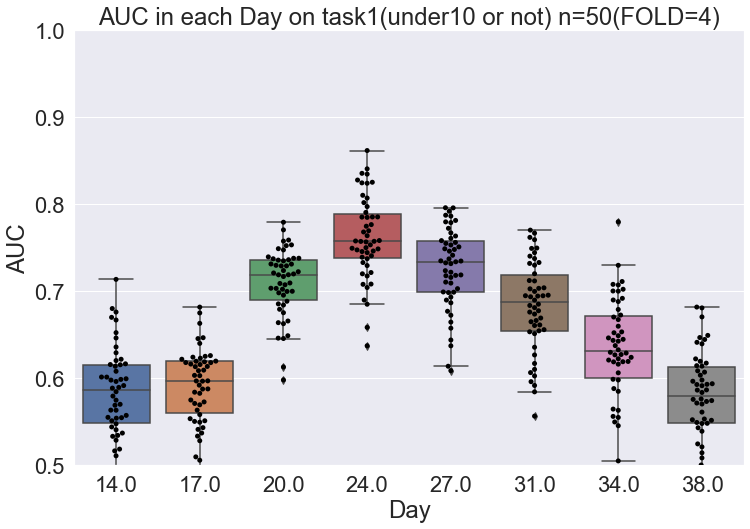

In [12]:
results10 = pd.read_csv(savefolder+"/task10under"+"/Task1FOLD_4_n=50_result_bugfixed.csv")
plt.figure(figsize=(12,8))

sns.set(font_scale = 2)
p = sns.boxplot(data=results10, x='Day', y='AUC')
p = sns.swarmplot(data=results10, x='Day', y='AUC', color="black")
#p = sns.violinplot(data=results10, x='Day', y='AUC')
p.set_ylim(0.5, 1.0)
p.set_title("AUC in each Day on task1(under10 or not) n=50(FOLD=4)")
plt.savefig(savefolder+"/under10.svg")

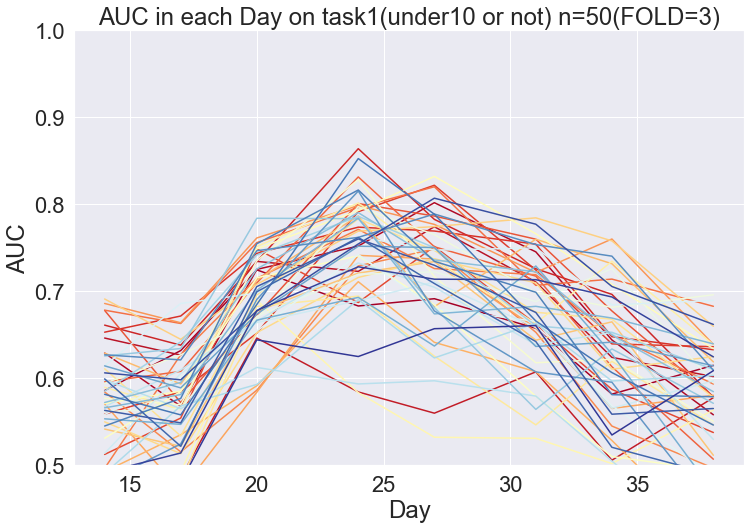

In [26]:
plt.figure(figsize=(12,8))
sns.set(font_scale = 2)

p = sns.lineplot(data=results10, x='Day', y='AUC', hue="seed", palette='RdYlBu')
plt.legend([],[], frameon=False)
p.set_ylim(0.5, 1.0)
p.set_title("AUC in each Day on task1(under10 or not) n=50(FOLD=3)")
plt.show()

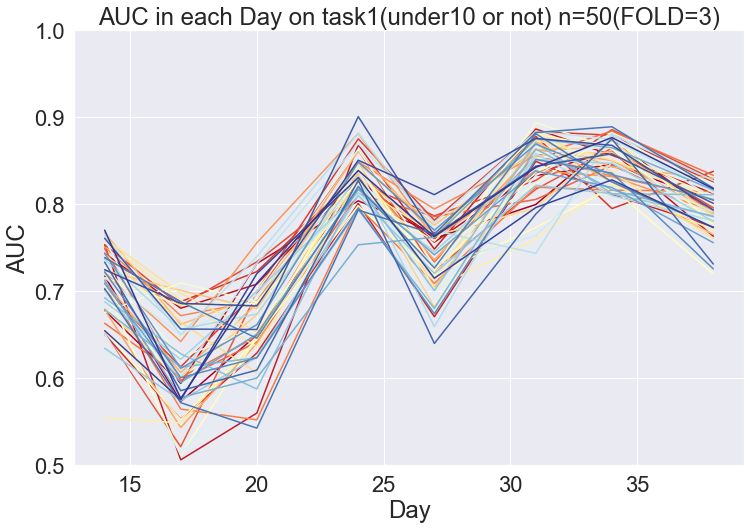

In [27]:
plt.figure(figsize=(12,8))
sns.set(font_scale = 2)

p = sns.lineplot(data=results20, x='Day', y='AUC', hue="seed", palette='RdYlBu')
plt.legend([],[], frameon=False)
p.set_ylim(0.5, 1.0)
p.set_title("AUC in each Day on task1(under10 or not) n=50(FOLD=3)")
plt.show()